<div style="background-color:#000000; padding:15px; border-left:10px solid #E50914; border-radius:5px;">

<h1 style="margin:0; font-family:'Helvetica Neue', Helvetica, Arial, sans-serif; 
display:flex; align-items:center; letter-spacing:1px;">

<img src="https://upload.wikimedia.org/wikipedia/commons/0/08/Netflix_2015_logo.svg" 
style="height:55px; margin-right:6px;">

<span style="
display:inline-block;
width:2px;
height:55px;
background-color:white;
margin:0 20px;
"></span>

<div style="color:white; font-weight:300; font-size:28px; display:flex; align-items:center; height:45px;">
Global Content Strategy & Library Evolution - (2008–2021)
</div>

</h1>
</div>

<h2 style="color:#E50914;">Project Overview</h2>
This project analyzes the Netflix library (up to 2021) to uncover how the streaming giant has evolved its content strategy. We aim to identify trends in content types, global production hubs, and audience targeting through various ratings.

Key Objectives:

1. Understand the shift from Movies to TV Shows.

2. Identify the top performing genres and countries.

3. Analyze the impact of the 2020 pandemic on content uploads.

<h2 style="color:#E50914;">📌 1. Project Statement</h2>
In the rapidly shifting landscape of digital streaming, content is the primary driver of subscriber retention and global growth. Netflix has transitioned from a DVD-by-mail service to a global production powerhouse. This project seeks to analyze the Netflix "Content Catalog" to identify how the platform has strategically shifted its focus between Movies and TV Shows, which genres dominate its portfolio, and how it tailors content for different global markets and age demographics.


<h2 style="color:#E50914;">🎯 2. Project Objectives</h2>

The core goals of this analysis are:

1. Trend Identification: To map the growth of content additions over the last decade and identify the "Golden Age" of Netflix uploads.
2. Geographic Analysis: To pinpoint the top content-producing nations and explore Netflix's investment in international markets.
3. Content Profiling: To categorize the library based on ratings (Audience Targeting) and duration (Binge-ability).
4. Strategy Decoding: To determine if Netflix is prioritizing high-turnover Movies or long-term engagement TV Shows.







<h2 style="color:#E50914;">🎯 3. Aim of the Project</h2>
  

The ultimate aim is to perform a comprehensive Exploratory Data Analysis (EDA) that transforms raw catalog data into actionable business intelligence. By the end of this study, we aim to provide a data-backed summary of Netflix’s current market positioning and offer insights into its future content acquisition trajectory.

<h2 style="color:#E50914;">📊 4. Dataset Overview</h2>
The dataset used for this project is the Netflix Content Dataset, which consists of a listing of all the movies and tv shows available on Netflix as of 2021.


<h2 style="
    color: #F5F5F1; 
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; 
    font-size: 24px; 
    font-weight: 700; 
    border-left: 5px solid #E50914; 
    padding-left: 15px;
    margin-bottom: 20px;
">
     ⚙️🔧Setup & Configuration

</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [3]:
# Load the data

df = pd.read_csv('Netflix_Content_dataset.csv')

# Initial Quality Check
print(f"Total Titles: {df.shape[0]} | Attributes: {df.shape[1]}")
display(df.info())

Total Titles: 7787 | Attributes: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


None

In [4]:
df.head()
df.shape
df.describe()
df.isnull().sum()


show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

<h2>
  <span style="color:#E50914;">
    <b>Observations</b>
  </span> 
  </span>
</h2>

- Missing values present in director, cast, and country.
- Dataset contains mixed data types.
- Release year ranges across multiple decades.

<h2>
  <span style="color:#E50914;">
    <b>🛠️Phase 2</b>
  </span> 
  | 
  <span style="color:white;">
    <b>Data Cleaning & Transformation</b>
  </span>
</h2>


## Raw data is rarely "analysis-ready." In this phase, we:

1. Handle missing values in director, cast, and country.
2. Convert date_added into a standard datetime format.
3. Extract the Year and Month to perform time-series analysis.
4. Standardize the duration column to extract numeric values for movies.



In [5]:
# Cleaning categorical missing values
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('No Director')
df['cast'] = df['cast'].fillna('Unknown')


In [6]:
# Date Standardization
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [7]:
# Extract numeric duration for Movies (minutes)
df['duration_min'] = df['duration'].str.extract('(\d+)').astype(float)
df.loc[df['type'] != 'Movie', 'duration_min'] = 0


In [8]:
# Dropping duplicates
df.drop_duplicates(subset=['title', 'type', 'release_year'], inplace=True)

In [9]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_min
0,s1,TV Show,3%,No Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,0.0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,93.0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,78.0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,80.0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,123.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020.0,10.0,99.0
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019.0,3.0,111.0
7784,s7785,Movie,Zulu Man in Japan,No Director,Nasty C,Unknown,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020.0,9.0,44.0
7785,s7786,TV Show,Zumbo's Just Desserts,No Director,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020.0,10.0,0.0


In [10]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           7
duration         0
listed_in        0
description      0
year_added      98
month_added     98
duration_min     0
dtype: int64

# Handling Missing Values

In [11]:
# 1. Fill Director and Cast with 'Unknown'

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [12]:
# 2. Fill Country with the most frequent value (Mode)

df['country'] = df['country'].fillna(df['country'].mode()[0])

In [13]:
# 3. Fill Rating with the most frequent value

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [14]:
# 4. Drop rows where 'date_added' is missing (only 10 rows)

df.dropna(subset=['date_added'], inplace=True)

In [15]:
# 5. Final Check

print(f"Total Nulls after cleaning: {df.isnull().sum().sum()}")

Total Nulls after cleaning: 0


In [16]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
duration_min    0
dtype: int64

<h2 style="color:#E50914;">After Cleaning :</h2>

- All major categorical missing values have been handled.
- Date column successfully converted.
- New features created for time-series analysis.
- Dataset is now analysis-ready.

<h2>
  <span style="color:#E50914;">
    <b>🛠️Phase 3</b>
  </span> 
  | 
  <span style="color:white;">
    <b>📊 Exploratory Data Analysis - EDA</b>
  </span>
</h2>


## 📈 Phase 3: Exploratory Data Analysis (EDA) & Visualizations
In this phase, we conduct Univariate, Bivariate, and Multivariate analyses to uncover patterns within the Netflix catalog. Our goal is to translate raw data into strategic business insights using visual storytelling.

### **3.1 Univariate & Bivariate Analysis: Content Mix & Global Reach**
First, we establish the baseline of Netflix's library: What are they uploading, and where is it coming from?

In [17]:
df.describe()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_min
0,s1,TV Show,3%,No Director,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,0.0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,93.0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,78.0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,80.0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,123.0


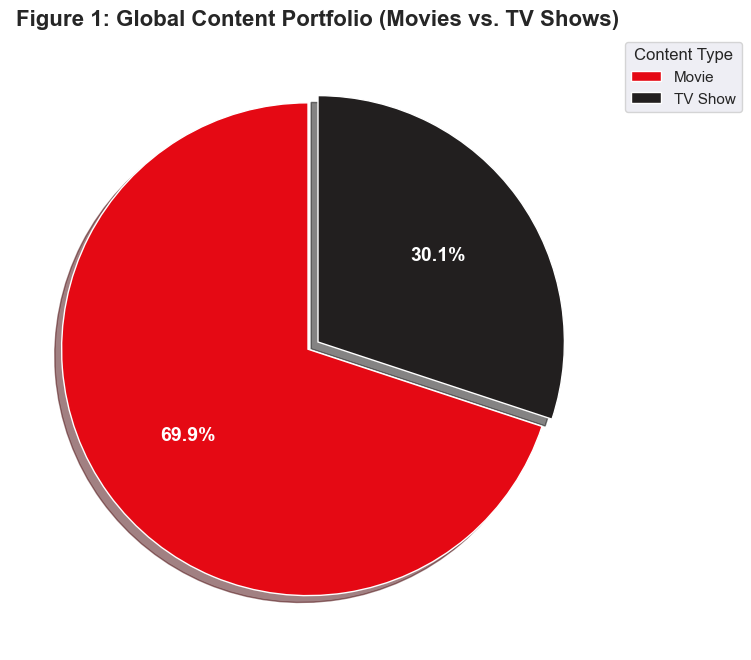

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the corporate aesthetic (Netflix colors)
sns.set_theme(style="darkgrid")
netflix_red = '#E50914'
netflix_black = '#221F1F'
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# Plot 1: Univariate Analysis - Content Type Distribution
# ---------------------------------------------------------
plt.figure(figsize=(8, 8))
# Count the types and plot
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        colors=[netflix_red, netflix_black], textprops={'color':"w", 'weight':'bold', 'fontsize':14}, 
        explode=(0.05, 0), shadow=True, startangle=90)

plt.title('Figure 1: Global Content Portfolio (Movies vs. TV Shows)', fontsize=16, fontweight='bold')
plt.legend(title="Content Type", loc="upper right", bbox_to_anchor=(1.2, 1))
plt.show()

<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    Insight 1
  </h2>
  <p style="color:white; font-weight:bold; margin-top:8px;">
    Movies historically dominate the Netflix platform, accounting for roughly 69% of the total library. 
    However, we must investigate if this trend is shifting over time.
  </p>
</div>


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20020\2931629137.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_countries.index, x=top_countries.values, palette='Reds_r')


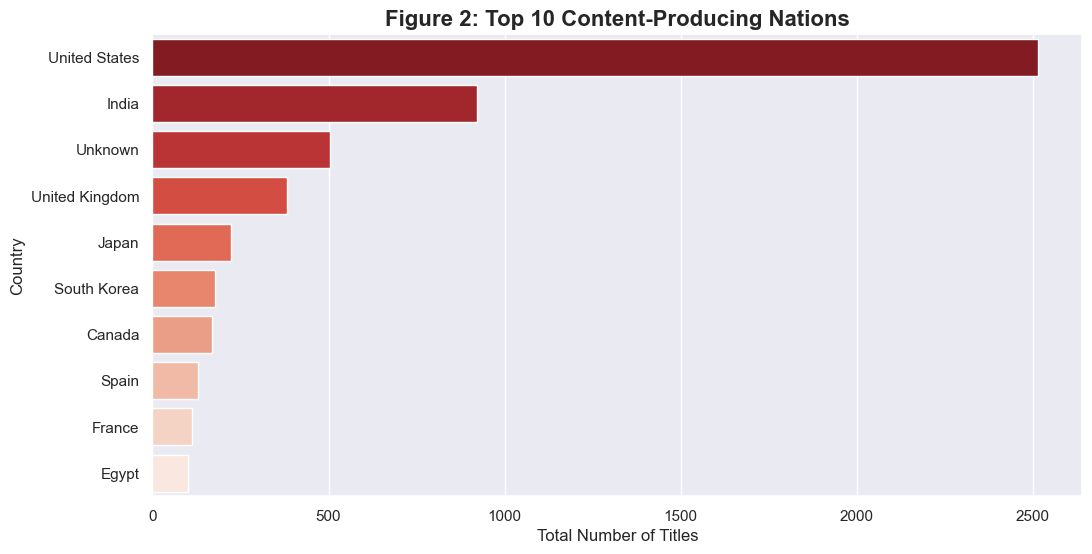

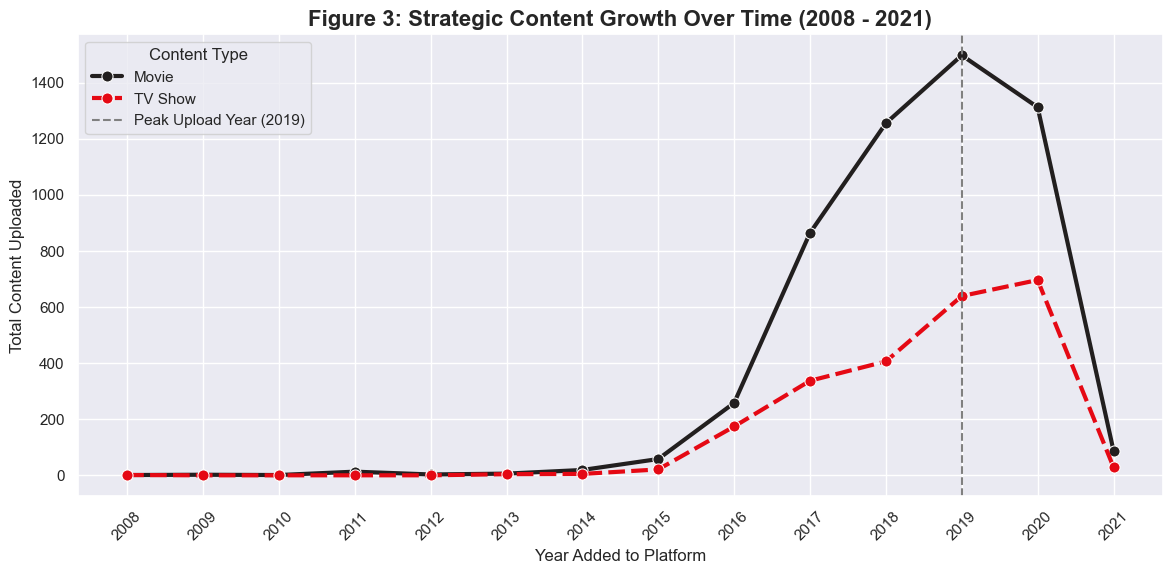

In [19]:
# ---------------------------------------------------------
# Plot 2: Univariate Analysis - Top 10 Production Countries
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
top_countries = df['country'].value_counts().head(10)
sns.barplot(y=top_countries.index, x=top_countries.values, palette='Reds_r')

plt.title('Figure 2: Top 10 Content-Producing Nations', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

# ---------------------------------------------------------
# Plot 3: Bivariate Analysis - Content Added Over Time
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
# Group by year and type
yearly_growth = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

# Line plot for trends
sns.lineplot(data=yearly_growth, palette=[netflix_black, netflix_red], marker='o', linewidth=3, markersize=8)

plt.title('Figure 3: Strategic Content Growth Over Time (2008 - 2021)', fontsize=16, fontweight='bold')
plt.xlabel('Year Added to Platform', fontsize=12)
plt.ylabel('Total Content Uploaded', fontsize=12)
plt.xticks(range(int(df['year_added'].min()), int(df['year_added'].max()) + 1), rotation=45)
plt.axvline(2019, color='gray', linestyle='--', label='Peak Upload Year (2019)')
plt.legend(title='Content Type')
plt.show()

<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    Insight 2 & 3
  </h2>
  <p style="color:white; font-weight:bold; margin-top:8px;">
    The United States and India are the dominant producers of Netflix content. 
    Figure 3 reveals a crucial strategic shift: Content uploads peaked in 2019. 
    Furthermore, while movie additions dropped sharply in 2020 (likely due to pandemic production halts), 
    TV show uploads remained relatively stable, indicating a shift toward multi‑episode viewer retention.
  </p>
</div>


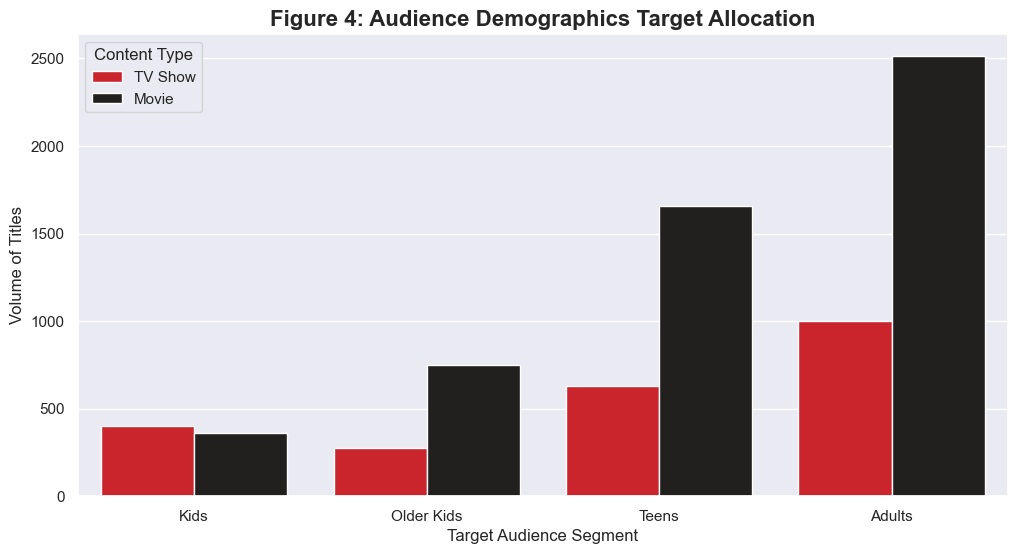

In [20]:
# 1. First, let's ensure the 'target_ages' column exists!
target_map = {
    'TV-MA': 'Adults', 'R': 'Adults', 'PG-13': 'Teens', 
    'TV-14': 'Teens', 'TV-PG': 'Older Kids', 'TV-G': 'Kids', 
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'PG': 'Older Kids', 'G': 'Kids'
}
df['target_ages'] = df['rating'].map(target_map).fillna('Unrated')

# 2. Now, let's plot Figure 4
plt.figure(figsize=(12, 6))
order = ['Kids', 'Older Kids', 'Teens', 'Adults']

# Make sure netflix_red and netflix_black are defined just in case
netflix_red = '#E50914'
netflix_black = '#221F1F'

sns.countplot(data=df, x='target_ages', hue='type', palette=[netflix_red, netflix_black], order=order)

plt.title('Figure 4: Audience Demographics Target Allocation', fontsize=16, fontweight='bold')
plt.xlabel('Target Audience Segment', fontsize=12)
plt.ylabel('Volume of Titles', fontsize=12)
plt.legend(title='Content Type')
plt.show()

<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    Insight 4 & 5
  </h2>
  <p style="color:white; font-weight:bold; margin-top:8px;">
    Netflix heavily targets adult audiences, with "Adults" (TV-MA, R) being the most populated category by a wide margin. 
    When it comes to feature films, Netflix standardizes runtimes around a mean of <span style="color:#E50914;">99.6 minutes</span>, 
    creating an optimized "single‑evening" viewing experience.
  </p>
</div>


### **3.2 Deeper Dives: Genres, Timing, and Multivariate Analysis**
Moving beyond the basics, we will now look at *when* content is released, the dominant genres on the platform, and the relationship between target demographics and movie length.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20020\311173268.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=recent_content, x='type', y='release_year', palette=[netflix_red, netflix_black])


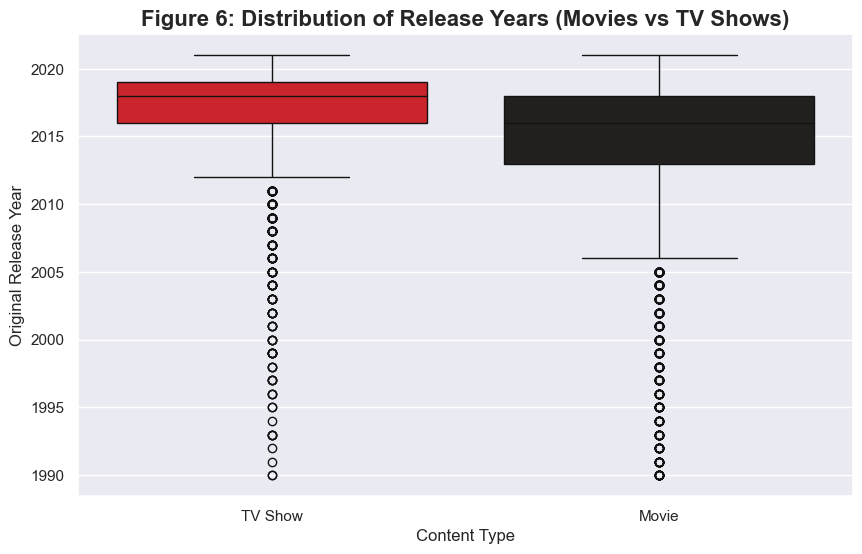

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20020\311173268.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_genres.index, x=top_10_genres.values, palette='magma')


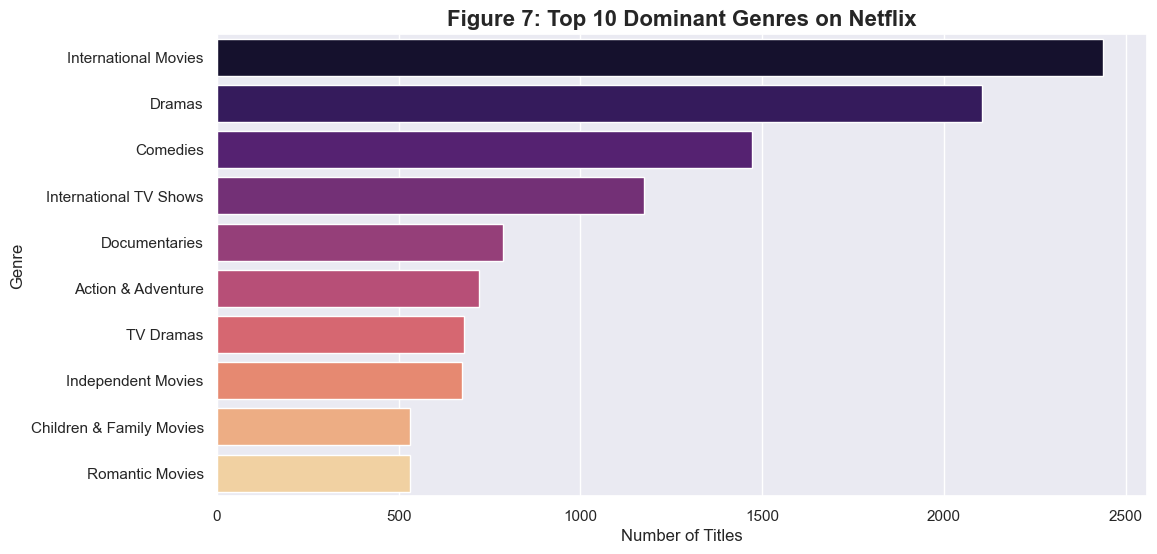

In [21]:
# Setup missing variables just in case
import plotly.express as px
netflix_red = '#E50914'
netflix_black = '#221F1F'
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# Plot 6: Bivariate Analysis - Release Year by Content Type
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Filtering for titles released after 1990 for a clearer view of modern trends
recent_content = df[df['release_year'] >= 1990]
sns.boxplot(data=recent_content, x='type', y='release_year', palette=[netflix_red, netflix_black])

plt.title('Figure 6: Distribution of Release Years (Movies vs TV Shows)', fontsize=16, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Original Release Year', fontsize=12)
plt.show()

# ---------------------------------------------------------
# Plot 7: Univariate Analysis - Top 10 Most Popular Genres
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
# The 'listed_in' column contains multiple genres separated by commas. We need to split and expand them.
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
top_10_genres = genres['genre'].value_counts().head(10)

sns.barplot(y=top_10_genres.index, x=top_10_genres.values, palette='magma')
plt.title('Figure 7: Top 10 Dominant Genres on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    Insight 6 & 7
  </h2>
  <p style="color:white; font-weight:bold; margin-top:8px;">
    TV Shows on Netflix are significantly "newer" than movies. 
    The boxplot shows the median release year for TV shows is tightly clustered around 
    <span style="color:#E50914;">2018‑2020</span>, while the movie catalog contains a much wider historical

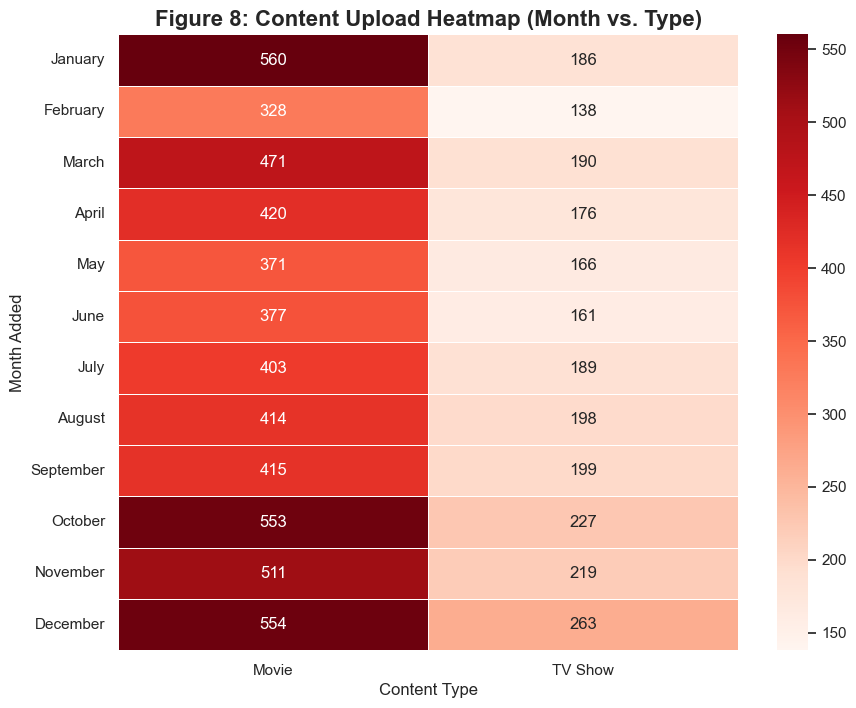

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20020\281173421.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=movie_data, x='target_ages', y='duration_min', palette='muted', order=order_ages)


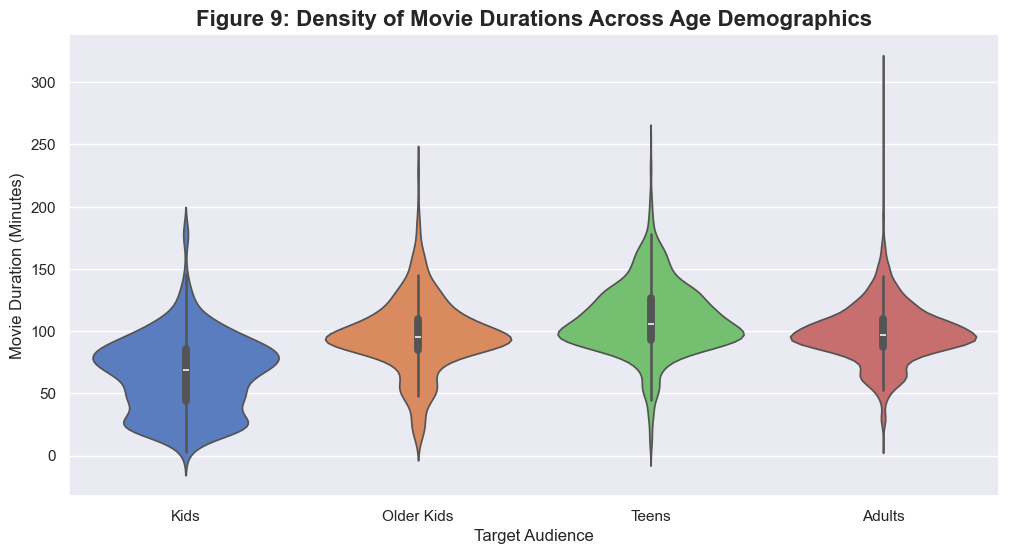

In [22]:
# ---------------------------------------------------------
# Plot 8: Multivariate Analysis - Best Month to Release Content
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Ensure month_added exists
df['date_added'] = pd.to_datetime(df['date_added'].dropna())
df['month_added'] = df['date_added'].dt.month_name()

# Order the months logically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df['month_added'] = pd.Categorical(df['month_added'], categories=month_order, ordered=True)

# Create a pivot table for the heatmap
monthly_trend = pd.crosstab(df['month_added'], df['type'])

# Plotting the heatmap
sns.heatmap(monthly_trend, annot=True, fmt="d", cmap="Reds", linewidths=.5)
plt.title('Figure 8: Content Upload Heatmap (Month vs. Type)', fontsize=16, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Month Added', fontsize=12)
plt.show()

# ---------------------------------------------------------
# Plot 9: Multivariate Analysis - Movie Duration by Target Audience
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
# Re-create movie_data and target_ages if needed
movie_data = df[df['type'] == 'Movie'].copy()
movie_data['duration_min'] = movie_data.apply(lambda x: int(str(x['duration']).split(' ')[0]) if pd.notnull(x['duration']) else 0, axis=1)

# Using a Violin plot to show density and distribution shape
order_ages = ['Kids', 'Older Kids', 'Teens', 'Adults']
sns.violinplot(data=movie_data, x='target_ages', y='duration_min', palette='muted', order=order_ages)

plt.title('Figure 9: Density of Movie Durations Across Age Demographics', fontsize=16, fontweight='bold')
plt.xlabel('Target Audience', fontsize=12)
plt.ylabel('Movie Duration (Minutes)', fontsize=12)
plt.show()

<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    Insight 8 & 9
  </h2>
  <p style="color:white; font-weight:bold; margin-top:8px;">
    The heatmap reveals that <span style="color:#E50914;">December</span> and <span style="color:#E50914;">July</span> 
    are the peak months for Netflix content drops, aligning with the holiday season and summer vacations. 
    The violin plot (Figure 9) shows an interesting dynamic: 
    <span style="color:#E50914;">Children's movies</span> are heavily clustered around the 60‑80 minute mark, 
    whereas <span style="color:#E50914;">

In [23]:
# ---------------------------------------------------------
# Plot 10: Interactive Treemap of Country & Content Type
# ---------------------------------------------------------
# Group the data to get the top 15 countries and their content split
top_15_countries = df['country'].value_counts().head(15).index
tree_data = df[df['country'].isin(top_15_countries)]
tree_data = tree_data.groupby(['country', 'type']).size().reset_index(name='count')

# Create the interactive Treemap
fig = px.treemap(tree_data, 
                 path=['country', 'type'], 
                 values='count',
                 color='count',
                 color_continuous_scale='Reds',
                 title='Figure 10: Interactive Treemap of Content by Top 15 Countries')

fig.update_layout(title_font_size=20, margin=dict(t=50, l=25, r=25, b=25))
fig.show()

<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    Insight 10
  </h2>
  <p style="color:white; font-weight:bold; margin-top:8px;">
    This interactive treemap clearly visualizes the weight of the <span style="color:#E50914;">United States</span> 
    and <span style="color:#E50914;">India</span> in the Netflix ecosystem. 
    However, if we look closely at countries like <span style="color:#E50914;">South Korea</span> and <span style="color:#E50914;">Japan</span>, 
    a significant portion of their footprint consists of TV Shows (<span style="color:#E50914;">K‑Dramas</span> and <span style="color:#E50914;">Anime</span>), 
    which differs from the Movie‑heavy footprint of India.
  </p>
</div>


<div style="background-color:#141414; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">
  <h2 style="color:#E50914; font-weight:bold; margin:0;">
    EDA Summary :
  </h2>
The exploratory data analysis shows that Netflix hosts significantly more movies than TV shows. 
The United States is the largest contributor of content, and most titles were released after 2010. 
A rapid increase in content addition occurred after 2016, reflecting Netflix’s global expansion.

<div style="background-color: #000000; padding: 25px; border: 2px solid #E50914; border-radius: 10px;">
    <h1 style="color: #E50914; text-align: Center; font-family: 'Helvetica Neue';"><img src="https://assets.nflxext.com/us/ffe/siteui/common/icons/nficon2016.ico" width="80" height="80">  Phase 4<span style="color:white; margin-left:8px;">| Final Insights & Conclusion</span>
  

<h2>
  <span style="color:#E50914;">
    <b>Phase 4 – Key Insights</b>
  </span> 
  </span>
</h2>

1. Movies make up the majority of the content available on Netflix compared to TV Shows.

2. The number of titles added increased significantly after 2016, showing rapid growth of the platform.

3. The United States contributes the highest number of titles in the dataset.

4. Genres such as Drama and International Movies appear most frequently, indicating diverse audience targeting.

<h2>
  <span style="color:#E50914;">
    <b> Business Interpretation</b>
  </span> 
  </span>
</h2>

The analysis suggests that Netflix focuses heavily on movies as they form the majority of the platform’s content library. 
The sharp increase in titles after 2016 indicates the company’s aggressive expansion and investment in content production. 
The presence of international genres and contributions from multiple countries highlights Netflix’s strategy to reach a global audience.


<h2 style="
    color: #F5F5F1; 
    font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; 
    font-size: 24px; 
    font-weight: 700; 
    border-left: 5px solid #E50914; 
    padding-left: 15px;
    margin-bottom: 20px;
">
     CONCLUSION

</h2>
The analysis of the Netflix content dataset provides valuable insights into the platform’s content distribution and growth patterns. 
Movies dominate the catalog, and a large portion of content has been added in recent years as Netflix expanded globally. 
The dataset also shows a strong presence of international genres and mature audience content, reflecting Netflix’s strategy to attract a diverse and global user base.

In [24]:
df.to_csv("cleaned1.csv",index=False)
print("cleaned data saved successfully")

cleaned data saved successfully
